# Pima Indians Diabetes — Classification Project

**Author:** Riya Kumari
**Date:** May 2026
**Goal:** Build and compare ML models to predict diabetes from medical features.

## Dataset
Pima Indians Diabetes Database — 768 patient records with 8 medical features (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age) and a binary Outcome label (1 = diabetes, 0 = no diabetes).

## Approach
1. Load and explore the data (EDA)
2. Clean: replace biologically impossible zeros with NaN, impute with median
3. Split: stratified 80/20 train/test
4. Train: Logistic Regression baseline + Random Forest comparison
5. Evaluate: accuracy, precision, recall, F1, ROC-AUC

## Key Result
**Random Forest outperformed Logistic Regression** on all key metrics (78% accuracy, 0.82 AUC, 59% diabetes recall vs LR's 70%/0.81/50%).


## 1. Load the Dataset

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=columns)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Explore the Data (EDA)

In [ ]:
# Cell 2: Quick look
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Cell 3: Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Cell 4: Statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Cell 5: Shape (rows, columns)
df.shape

(768, 9)

In [ ]:
# Cell 6: Check missing values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### 2.1 Feature Distributions

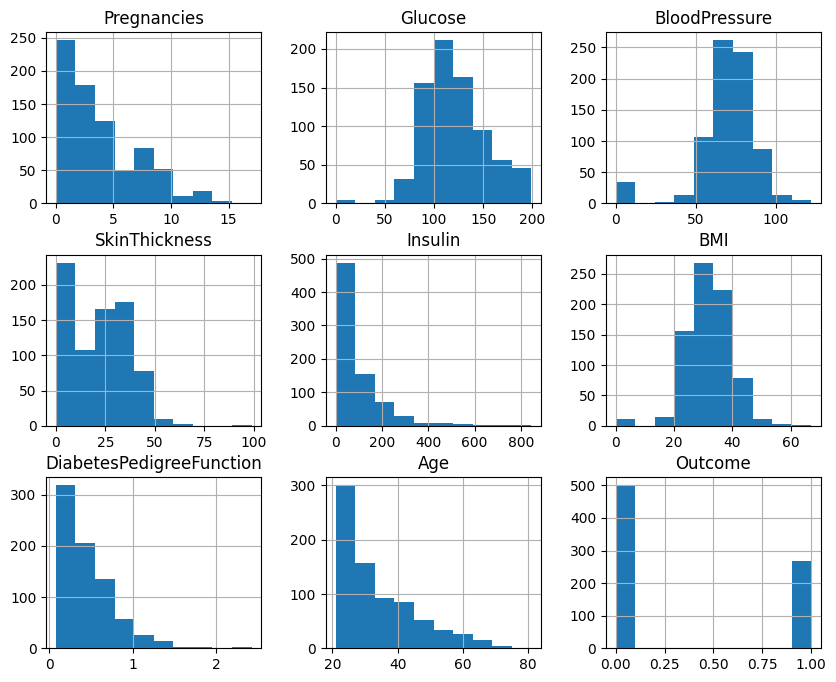

In [ ]:
# Cell 7: Histograms
df.hist(figsize=(10, 8));

### 2.2 What surprised me in the data

- **Outcome is imbalanced** — ~65% non-diabetic vs ~35% diabetic. This is why `stratify=y` matters during train-test split.
- **Insulin has a massive spike at 0** — these aren't real measurements but missing values in disguise. Need to be replaced with NaN before any analysis.
- **SkinThickness and BMI also show suspicious zero spikes** — biologically impossible, so these are hidden missing values too.
- **Age is heavily right-skewed** — most patients are young (20–30). Median would be a better fill strategy than mean.

### 3. Clean the Data

In [ ]:
import numpy as np

# columns where 0 means "missing", not a real measurement
cols_with_hidden_nans = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

# replace 0 with NaN on those columns only
df[cols_with_hidden_nans] = df[cols_with_hidden_nans].replace(0,np.nan)

# confirm: now isnull().sum() should show real missing counts
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### 3.1 Impute Missing Values with Median

In [ ]:
# filling missing values with the median of each column
for col in cols_with_hidden_nans:
   df[col] = df[col].fillna(df[col].median())
# verify all NaN are gone
df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## 4. Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split
# Separate feature (x) from target (y)
x = df.drop('Outcome', axis=1) # all columns EXCEPT Outcome
y = df['Outcome']            #only the Outcome column

# Split 80% train, 20% test
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42, stratify=y)

# Check the shapes to conform the splits worked
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))





x_train shape: (614, 8)
x_test shape: (154, 8)
y_train distribution:
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
y_test distribution:
 Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


## 5. Baseline Model - Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
# Create the model with default setting, but bump max_iter so it converges
model = LogisticRegression (max_iter=1000)
# Train (fit) the model on the training data
model.fit(x_train, y_train)
# Make prediction in the test set
y_pred = model.predict(x_test)
# Print the first 10 predictions and actual value to see them
print("Predicted:",y_pred[:10])
print("Actual:",y_test.values[:10])





Predicted: [1 0 0 0 0 0 0 1 0 1]
Actual: [0 0 0 1 0 0 1 1 0 0]


In [ ]:
from sklearn.metrics import accuracy_score
# Calculate accuracy: % of predictions that matched the actual outcome
accuracy = accuracy_score(y_test, y_pred)
print(f"test Accuracy:{accuracy:.4f}")
print(f"That's{accuracy*100:.2f}%")


test Accuracy:0.7013
That's70.13%


## Mini-Reflection: Is accuracy alone enough?

**My accuracy: 70.13%**

Is this number enough to know if my model is good? Why or why not?

[Accuracy alone isn't enough because it hides important information. My model got 70% — but if I had just predicted "no diabetes" for every patient, I would've gotten 65% just from class imbalance. So my model only learned 5% worth of real signal. More importantly, I noticed earlier that the model missed real diabetes cases (false negatives). In a medical setting, missing a sick patient is much worse than wrongly flagging a healthy one — but accuracy treats both errors equally. That's why the Kaggle author used Precision, Recall, and ROC-AUC instead. Tomorrow on Day 6, I need to look at those metrics, not just accuracy.]

## 6. Evaluate Logistic Regression

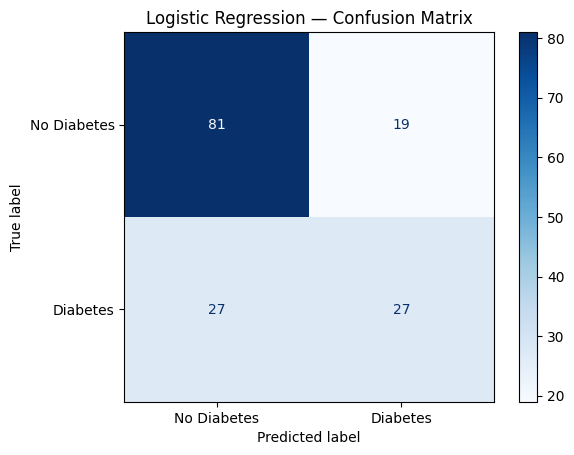

Confusion Matrix:
[[81 19]
 [27 27]]


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

# Also print the raw numbers
print("Confusion Matrix:")
print(cm)

### 6.1 Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Print full evaluation report
print("Classification Report — Logistic Regression\n")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

Classification Report — Logistic Regression

              precision    recall  f1-score   support

 No Diabetes       0.75      0.81      0.78       100
    Diabetes       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



### 6.2 ROC Curve

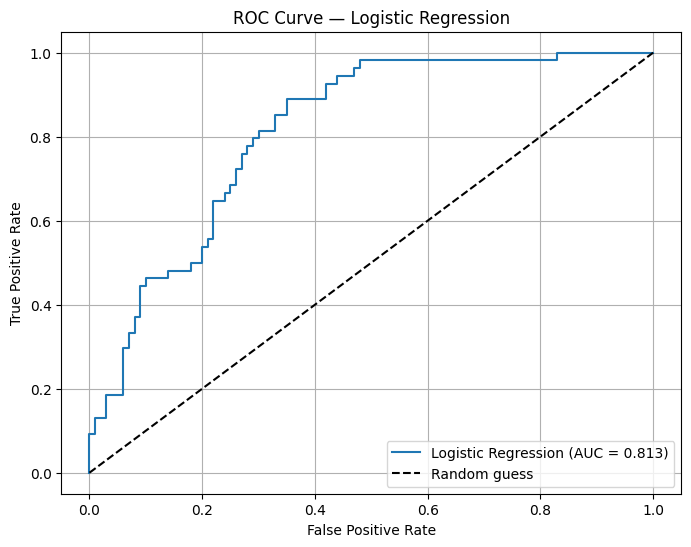

AUC Score: 0.8130


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get the model's probability predictions for the diabetes class
y_pred_proba = model.predict_proba(x_test)[:, 1]

# Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC Score: {auc:.4f}")

## 7. Comparison Model - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create and train a Random Forest with default settings
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)

# Make predictions
rf_pred = rf_model.predict(x_test)
rf_pred_proba = rf_model.predict_proba(x_test)[:, 1]

# Evaluate
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_pred_proba)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest AUC:      {rf_auc:.4f}\n")
print("Classification Report — Random Forest")
print(classification_report(y_test, rf_pred, target_names=['No Diabetes', 'Diabetes']))

Random Forest Accuracy: 0.7792
Random Forest AUC:      0.8192

Classification Report — Random Forest
              precision    recall  f1-score   support

 No Diabetes       0.80      0.88      0.84       100
    Diabetes       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



## 8. Side-By-Side ROC Comparison

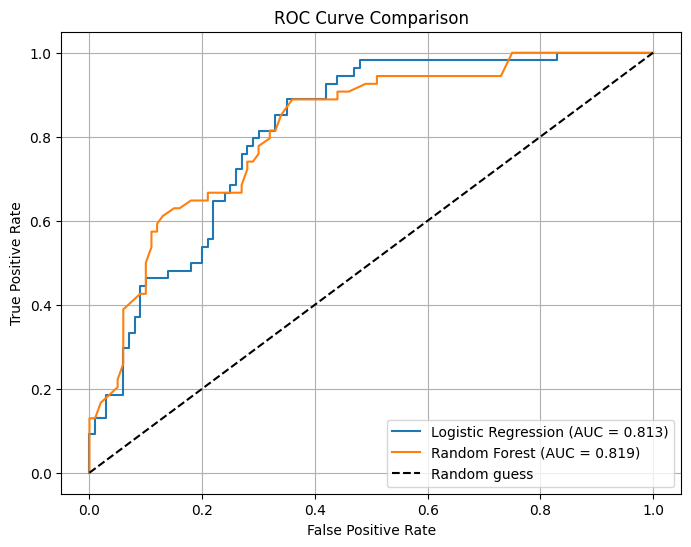

In [ ]:
# Get ROC curve points for Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)

# Plot both curves together
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()


## Model Comparison Conclusion

**Random Forest wins on all three key metrics:**

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 0.70 | **0.78** |
| AUC | 0.81 | **0.82** |
| Diabetes Recall | 0.50 | **0.59** |

**Key insight:** The most important win is **Diabetes Recall** — Random Forest catches 59% of real diabetic patients vs Logistic Regression's 50%. In a medical screening context, missing diabetic patients (false negatives) is much worse than wrongly flagging healthy ones, so recall on the positive class matters more than overall accuracy.

**Lesson learned:** Always compare multiple models. Default logistic regression looked "okay" at 70% accuracy, but Random Forest with the same default settings did meaningfully better — especially on the metric that matters most.